In [1]:
## Parallel programming imports
import ipyparallel as ipp
from mpi4py import MPI
cluster = ipp.Cluster(engines = "mpi", n = 5)
rc = cluster.start_and_connect_sync()

Starting 5 engines with <class 'ipyparallel.cluster.launcher.MPIEngineSetLauncher'>


  0%|          | 0/5 [00:00<?, ?engine/s]

In [2]:
%%px

import importlib.util

if importlib.util.find_spec("petsc4py") is not None:
    import dolfinx

    if not dolfinx.has_petsc:
        print("This demo requires DOLFINx to be compiled with PETSc enabled.")
        exit(0)
    from petsc4py.PETSc import ScalarType  # type: ignore
else:
    print("This demo requires petsc4py.")
    exit(0)

# +
import sys
import time

import numpy as np
import petsc4py
from petsc4py import PETSc
import gmsh
import matplotlib.pyplot as plt
import pyvista
from scipy.interpolate import griddata
import matplotlib.colors as mcolors
from PIL import Image
import datetime


import ufl
from ufl import (FacetNormal, Measure, SpatialCoordinate, TestFunction, TrialFunction, 
                 div, dot, dx, grad, inner, lhs, rhs, system)

from dolfinx import fem, io, mesh, plot, la
from dolfinx.fem import (Constant,  Function, functionspace, assemble_scalar, 
                         dirichletbc, form, locate_dofs_topological, Function)
import dolfinx.fem.petsc as petsc
from dolfinx.fem.petsc import LinearProblem
from dolfinx.io import (gmshio, XDMFFile, VTXWriter)
from dolfinx.plot import vtk_mesh
from dolfinx.geometry import bb_tree, compute_colliding_cells, compute_collisions_points
from dolfinx.mesh import create_unit_square, locate_entities, meshtags, entities_to_geometry, create_submesh
from dolfinx.graph import partitioner_scotch

petsc4py.init(sys.argv)

In [3]:
%%px

#######################################################################################
# define global parameters here 
time_smoothing = 200.0
n_layers_lumped = 10/1 # 10mm of new lumped layer; 0.05mm per true layer 
delta_t = 0.1 # [s] 

# Define the problem parameters
rho = 4700.0 #[kg/m^3]
cp = 500.0 #[J/(kg*K)]
k = 20.0 #[W/(m*K)]

h_bulk_powder = 10.0 # [W/(m^2*K)]

T_heatplate = 500.0 # [K]
q_powder = h_bulk_powder * 300.0 # [W/m^2] where 300 is the temperature difference between powder and part

T_initial = 600.0 # [K]

# machine parameters 
v_laser = 1.0 # [m/s] https://www.sciencedirect.com/science/article/pii/S2238785424027923
P_laser = 250.0 # [W]
h_hatch_um = 100.0 # [um]
t_interlayer = 10.0 # [s]

x_probe = np.array([[0.05, 0.09, 0.01]]) # where to probe the temperature

#######################################################################################
# intermediate values 
h_hatch = h_hatch_um * 1e-6 # [m]
n_hatches = 0.1/h_hatch 
length_hatch = 0.1 # [m]
t_true = n_hatches * length_hatch / v_laser # [s]
ved = P_laser/(v_laser * h_hatch * t_true)

t_true_scanning = 0.1**2 / (h_hatch * v_laser) # [s]
E_tot_layer = P_laser * t_true_scanning # [J] 
E_tot = n_layers_lumped * E_tot_layer # [J]
t_tot = n_layers_lumped * (t_true + t_interlayer) # [s]
t_per_layer = t_true_scanning + t_interlayer # [s]

# important values: 
q_laserpower = time_smoothing * P_laser / 0.1**2 # [W/m^2]
t_adapt_scanning = t_true_scanning / time_smoothing # [s]

t = 0.0
t_end = 50 #n_layers_lumped * t_per_layer # [s]
n_timesteps = int(t_end/delta_t)

# short stability value 
stability_value = delta_t * k / (rho * cp * (0.1/40))

# print some values
print("Stability value: ", stability_value, "; is small?")
print("Total time: ", t_end, "s")
print("Laser applied for ", t_adapt_scanning / delta_t, " time steps")
print("Number of lumped layers: ", n_layers_lumped)

[stdout:0] Stability value:  0.00034042553191489364 ; is small?
Total time:  50 s
Laser applied for  5.000000000000001  time steps
Number of lumped layers:  10.0


[stdout:3] Stability value:  0.00034042553191489364 ; is small?
Total time:  50 s
Laser applied for  5.000000000000001  time steps
Number of lumped layers:  10.0


[stdout:1] Stability value:  0.00034042553191489364 ; is small?
Total time:  50 s
Laser applied for  5.000000000000001  time steps
Number of lumped layers:  10.0


[stdout:2] Stability value:  0.00034042553191489364 ; is small?
Total time:  50 s
Laser applied for  5.000000000000001  time steps
Number of lumped layers:  10.0


[stdout:4] Stability value:  0.00034042553191489364 ; is small?
Total time:  50 s
Laser applied for  5.000000000000001  time steps
Number of lumped layers:  10.0


In [4]:
%%px

list_geofiles = [
    "../BoxMeshes/BoxMesh_Layer0.geo"#,
    #"../BoxMeshes/BoxMesh_Layer1.geo",
    #"../BoxMeshes/BoxMesh_Layer2.geo",
    #"../BoxMeshes/BoxMesh_Layer3.geo"
]

gmsh.initialize()

top_marker, bottom_marker, sides_marker = 13, 14, 15

In [5]:
%%px

def create_mesh_from_geo(layer_): 
    file_name_ = list_geofiles[layer_]
    gmsh.open(file_name_)
    model = gmsh.model
    model_name = model.getCurrent()
    mesh_, cell_tags, facet_tags_ = gmshio.model_to_mesh( 
        model, 
        MPI.COMM_WORLD, 
        rank = 0,
        gdim = 3, 
        partitioner = dolfinx.mesh.create_cell_partitioner(mesh.GhostMode.shared_facet) 
    )
    mesh_.topology.create_connectivity(d0 = 3, d1 = 2)
    mesh_.topology.create_connectivity(d0 = 0, d1 = 3)
    print(len(cell_tags.values), "DOFs for this process")

    return mesh_, cell_tags, facet_tags_

#mesh1, cell_tags1, facet_tags1 = create_mesh_from_geo(0)


%px:   0%|          | 0/5 [00:00<?, ?tasks/s]

[stderr:2] Warning : Boolean fragments skipped - too few arguments
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


[stderr:1] Warning : Boolean fragments skipped - too few arguments
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


[stderr:3] Warning : Boolean fragments skipped - too few arguments
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


[stderr:4] Warning : Boolean fragments skipped - too few arguments
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


...

[output:2]

<Figure size 600x500 with 0 Axes>

[output:1]

<Figure size 600x500 with 0 Axes>

[output:0]

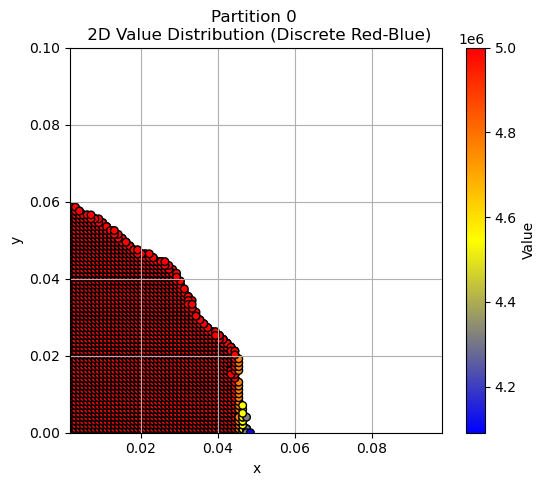

[output:2]

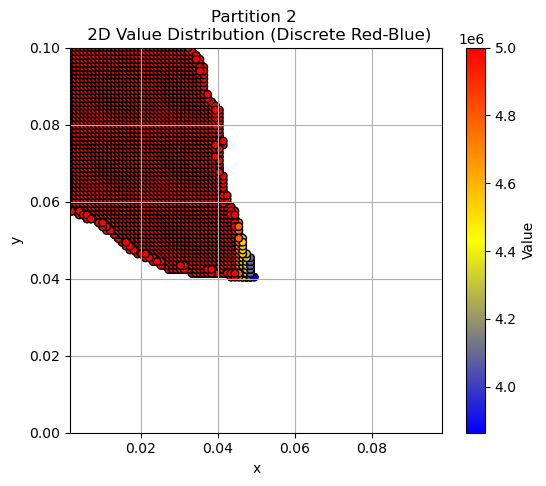

[output:3]

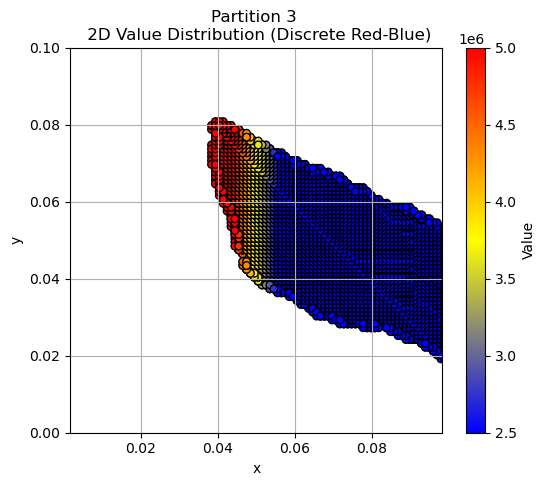

[output:1]

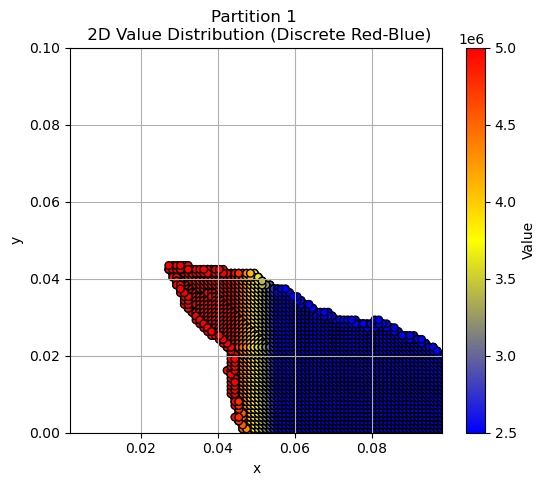

[output:4]

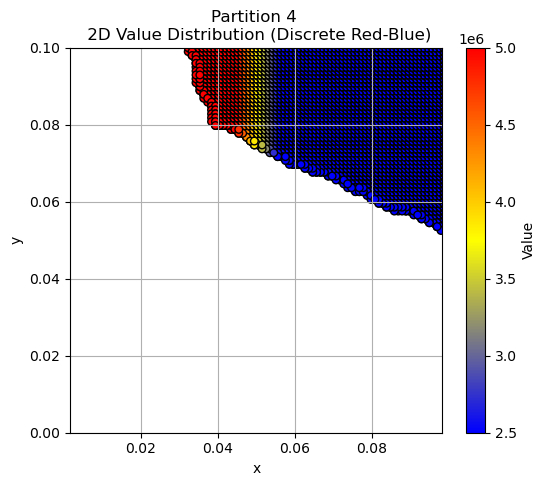

In [ ]:
%%px 

#####
 # temporary: plots the mesh and the power distribution
#####


# assign q_laserpower for x < 0.05 and q_laserpower/2 for x > 0.05
n = 10
points_ = np.array([[x, y] for x in np.linspace(0, 0.1, n) for y in np.linspace(0, 0.1, n)])
values = np.array([1]*int(n*n/2) + [0.5]*int(n*n/2)) * q_laserpower

listhaha = []
list_xy= []

def old_laser_power_interp(x):
    # x has shape (3, Npoints) even for surface functions (z may not be 0)
    x_y = np.vstack((x[0], x[1])).T  # extract (x,y) only
    #print(x_y)

    # Interpolate
    interpolated = griddata(points_, values, xi=x_y, method='linear', fill_value=0)
    listhaha.append(interpolated)
    list_xy.append(x_y)

    return interpolated


#print(lambda x: x[0] + x[1])
mesh1, cell_tags1, facet_tags1 = create_mesh_from_geo(0)
unit_cube_mesh = dolfinx.mesh.create_rectangle(
    MPI.COMM_WORLD, 
    points = ([0.0, 0.0], [0.1, 0.1]),
    n = [100, 100]
)

cube_mesh_functionspace = dolfinx.fem.functionspace(unit_cube_mesh, ("Lagrange", 1))
q_func_ = Function(cube_mesh_functionspace, name = "q_func_laserpower")

submesh, entity_map, vertex_map, node_map = create_submesh(mesh1, dim = 2, entities = facet_tags1.find(top_marker))
subspace = dolfinx.fem.functionspace(submesh, ("Lagrange", 1))

q_func = Function(subspace, name = "q_func_laserpower")
q_func.interpolate(old_laser_power_interp)

#print(q_func.x)

#sampling_point = np.array([[0.06, 0.0]])
#interpolated_value = griddata(points_, values, xi = sampling_point, method='linear', fill_value=0)

#print(list_xy[0])
#print(listhaha[0])


plt.figure(figsize=(6,5))

colors = ["blue", "yellow", "red"]
cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", colors)
norm = mcolors.Normalize(vmin=np.min(listhaha[0]), vmax=np.max(listhaha[0]))

# Plot
plt.figure(figsize=(6,5))
sc = plt.scatter(list_xy[0][:, 0], list_xy[0][:,1], c=listhaha[0], cmap=cmap, norm=norm, s=30, edgecolor='k')
plt.colorbar(sc, label='Value')
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'Partition {MPI.COMM_WORLD.rank} \n 2D Value Distribution (Discrete Red-Blue)')
plt.axis('equal')
plt.xlim(0, 0.1)
plt.ylim(0, 0.1)
plt.grid(True)
plt.show()

In [23]:
%%px 

# just for testing; TODO: import output array from agent into "output_laser"
# assign q_laserpower for x < 0.05 and q_laserpower/2 for x > 0.05
image = Image.open('doge_grey2_inverted_100x100.png').convert('L') # convert to grayscale values [0, 255] only
output_laser = np.asarray(image)/255.0 # convert to [0, 1] values
n = int(output_laser.shape[0])

output_laser = output_laser.flatten()
output_laser *= (2.0 * q_laserpower)

grid_coordinates = np.array([[x, y] for x in np.linspace(0, 0.1, n) for y in np.linspace(0, 0.1, n)])

#output_laser = np.array([1]*int(n*n/2) + [0.5]*int(n*n/2)) * q_laserpower


def laser_power_interp(x):
    x_y = np.vstack((x[0], x[1])).T  # extract (x,y) only
    # Interpolate
    interpolated = griddata(grid_coordinates, output_laser, xi=x_y, method='linear', fill_value=0)
    return interpolated


def apply_output_laser(V_, mesh_, facet_tags_): 
    #top_submesh, entity_map, vertex_map, node_map = create_submesh(mesh_, dim = 2, entities = facet_tags_.find(top_marker))
    #top_subspace = dolfinx.fem.functionspace(top_submesh, ("Lagrange", 1))

    q_func = Function(V_, name = "q_func_laserpower")
    q_func.interpolate(laser_power_interp)

    return q_func

In [24]:
%%px

def initialize_weakform(mesh_): 
    V_ = fem.functionspace(mesh_, ("Lagrange", 1))
    T_n_ = Function(V_) # previous time step

    return V_, T_n_

#V1, T_n1 = initialize_weakform(mesh1)
#T_n1.x.array[:] = T_initial

def setup_weakform(mesh_, V_, T_n_, facet_tags_): 
    #V_ = fem.functionspace(mesh_, ("Lagrange", 1))
    ds_ = Measure("ds", domain=mesh_, subdomain_data=facet_tags_)

    # Define the test function and trial function
    T_ = TrialFunction(V_)
    v_ = TestFunction(V_)
    #T_n_ = Function(V_) # previous time step
    x_ = SpatialCoordinate(mesh_)

    # define q_laserpower function 
    q_laserpower_func = apply_output_laser(V_, mesh_, facet_tags_)
    #ds_laser = Measure("ds", domain=top_submesh, subdomain_data=facet_tags_)
    

    # Define the variational form
    a_ = rho * cp * T_ * v_ * dx + delta_t * k * inner(grad(T_), grad(v_)) * dx
    L_laser_ = rho * cp * T_n_ * v_ * dx - inner((q_powder*delta_t), v_) * ds_(sides_marker) - inner((-q_laserpower_func*delta_t), v_) * ds_(top_marker)
    L_cooling_ = rho * cp * T_n_ * v_ * dx - inner((q_powder*delta_t), v_) * ds_(sides_marker) - inner((q_powder*delta_t), v_) * ds_(top_marker)

    return a_, L_laser_, L_cooling_ 

#a1, L_laser1, L_cooling1 = setup_weakform(mesh1, V1, T_n1, facet_tags1) 


In [25]:
%%px 

def create_boundary_conditions(mesh_, V_, facet_tags_): 
    u_D_ = Function(V_)
    u_D_.x.array[:] = T_heatplate 
    facets_ = facet_tags_.find(bottom_marker)
    dofs_ = locate_dofs_topological(V_, mesh_.topology.dim - 1, facets_)
    bcs_ = [dirichletbc(u_D_, dofs_)] # needs to be a list

    return bcs_

#bcs1 = create_boundary_conditions(mesh1, V1, facet_tags1)


In [26]:
%%px 

# assemble the system
def setup_system(F_laser_, F_cooling_): #--> not needed anymore if a and L_laser and L_cooling are used
    a_laser_, L_laser_ = system(F_laser_)
    a_cooling_, L_cooling_ = system(F_cooling_)
    return a_laser_, L_laser_, a_cooling_, L_cooling_

#a_laser1, L_laser1, a_cooling1, L_cooling1 = setup_system(F_laser1, F_cooling1)
#a_laser2, L_laser2, a_cooling2, L_cooling2 = setup_system(F_laser2, F_cooling2)


def compile_system(a_, L_laser_, L_cooling_, V_, bcs_): 
    compiled_a_ = fem.form(a_)
    A_ = petsc.assemble_matrix(compiled_a_, bcs=bcs_)
    A_.assemble()
    compiled_L_laser_ = fem.form(L_laser_)
    compiled_L_cooling_ = fem.form(L_cooling_)
    return A_, compiled_a_, compiled_L_laser_, compiled_L_cooling_

#A1, compiled_a1, compiled_L_laser1, compiled_L_cooling1 = compile_system(a1, L_laser1, L_cooling1, V1, bcs1)

def setup_solver(mesh_, A_): 
    solver_ = PETSc.KSP().create(mesh_.comm)
    solver_.setOperators(A_)
    solver_.setType("cg")
    pc_ = solver_.getPC()
    pc_.setType("jacobi")

    return solver_

#solver1 = setup_solver(mesh1, A1)

In [27]:
%%px

def get_ranks_containing_probingpoint(mesh_): 
    # Find which cell contains the point (do this only once if the mesh is static)
    tree_ = bb_tree(mesh_, mesh_.topology.dim)
    candidates_ = compute_collisions_points(tree_, x_probe)
    colliding_cells_ = compute_colliding_cells(mesh_, candidates_, x_probe)
    cell_ids_ = colliding_cells_.array

    rank_ = MPI.COMM_WORLD.Get_rank()

    if len(cell_ids_) > 0:
        cell_id_ = cell_ids_[0]  # Get the first (and only) cell ID
        owns_it_ = True # true on only one rank 
    else: 
        owns_it_ = False
        cell_id_ = None

    local_rank_value_ = rank_ if owns_it_ else MPI.COMM_WORLD.Get_size()

    owning_rank_ = MPI.COMM_WORLD.allreduce(local_rank_value_, op=MPI.MIN)

    if owning_rank_ < MPI.COMM_WORLD.Get_size():
        rank_contains_cellid_ = rank_ if rank_ == owning_rank_ else None
        rank_contains_cellid_ = MPI.COMM_WORLD.bcast(rank_contains_cellid_, root=owning_rank_)
    else:
        rank_contains_cellid_ = None  # Nobody owns the cell

    return rank_contains_cellid_, cell_id_

#rank_contains_cellid1, cell_id1 = get_ranks_containing_probingpoint(mesh1)


In [28]:
%%px

##########################################################
# main simulation loop 

def apply_thermal_to_mesh(V_, bcs_, compiled_a_, compiled_L_laser_, compiled_L_cooling_, T_n_, rank_contains_cellid_, cell_id_, solver_): 
    Tracker_Temperature = np.empty(n_timesteps)
    Tracker_time = np.empty(n_timesteps)
    Tracker_T_n = [] 
    t = 0.0 
    n_i = 0 

    start_time = time.time()

    compiled_L_ = compiled_L_laser_ # start with laser power
    b_ = Function(V_)
    uh_ = Function(V_)

    while t < (t_end - 1e-6): # 1e-6 is just to avoid rounding errors
        t += delta_t
        Tracker_time[n_i] = t

        t_in_cycle = t % t_per_layer
        t_in_cycle_earlier = (t - delta_t) % t_per_layer

        if (int(t // t_per_layer) < n_layers_lumped):
            if (t_in_cycle < t_adapt_scanning):
                compiled_L_ = compiled_L_laser_  # laser power
            else: 
                compiled_L_ = compiled_L_cooling_
        else: 
            compiled_L_ = compiled_L_cooling_ 

        # assemble RHS 
        b_.x.array[:] = 0.0
        petsc.assemble_vector(b_.x.petsc_vec, compiled_L_)

        # apply BCs 
        petsc.apply_lifting(b_.x.petsc_vec, [compiled_a_], [bcs_])
        b_.x.scatter_reverse(la.InsertMode.add)
        fem.petsc.set_bc(b_.x.petsc_vec, bcs_)

        # Solve linear problem
        solver_.solve(b_.x.petsc_vec, uh_.x.petsc_vec)
        uh_.x.scatter_forward()

        # Update Tn
        T_n_.x.array[:] = uh_.x.array
        Tracker_T_n.append(T_n_.x.array.copy())

        #print temperature at point on side face at z=0.1: 
        if rank_contains_cellid_ == MPI.COMM_WORLD.Get_rank():
            value = uh_.eval(x_probe, cell_id_)
            Tracker_Temperature[n_i] = value[0]
            if n_i % 1 == 0:
                print(f"Time {t:.6f} s: T({x_probe}) = {value[0]:.3f} K")
        
        n_i += 1

    end_time = time.time()
    print("It took", end_time - start_time, "s to solve the problem.")

    # send list to all ranks 
    Tracker_Temperature[:] = MPI.COMM_WORLD.bcast(Tracker_Temperature[:], root=rank_contains_cellid_)

    return Tracker_Temperature, Tracker_time, Tracker_T_n, T_n_


In [29]:
%%px
 
def fill_zeros_with_initial(T_n_: Function, T_initial: float):
    values = T_n_.x.array
    zero_mask = np.isclose(values, 0.0)
    values[zero_mask] = T_initial
    T_n_.x.array[:] = values


def interpolate_to_next_mesh(T_n_from, T_n_to, cell_tags_mesh_to, V_from, V_to):
    all_cells = np.arange(0, len(cell_tags_mesh_to.values)) # roughly 3x faster (0.2ms vs 0.6ms) than locate_entities(umesh, tdim, lambda x:np.full(x.shape[1],True,dtype=bool))
    interpolation_data = dolfinx.fem.create_interpolation_data(V_to, V_from, all_cells)
    T_n_to.interpolate_nonmatching(T_n_from, all_cells, interpolation_data) # None --> all cells are interpolated
    fill_zeros_with_initial(T_n_to, T_initial)
    T_n_to.x.scatter_forward()


In [30]:
%%px 

def setup_firstlayer(): 
    mesh, cell_tags, facet_tags = create_mesh_from_geo(0)
    V, T_n = initialize_weakform(mesh)
    T_n.x.array[:] = T_initial 

    return mesh, cell_tags, facet_tags, V, T_n


def setup_layer(layer_, V, T_n): 
    mesh2, cell_tags2, facet_tags2 = create_mesh_from_geo(layer_)
    V2, T_n2 = initialize_weakform(mesh2)
    interpolate_to_next_mesh(T_n, T_n2, cell_tags2, V, V2)
    V = V2
    T_n = T_n2 
    mesh, cell_tags, facet_tags = mesh2, cell_tags2, facet_tags2 

    return mesh, cell_tags, facet_tags, V, T_n
    
def initialize_layer(mesh, facet_tags, V, T_n):
    a, L_laser, L_cooling = setup_weakform(mesh, V, T_n, facet_tags) 
    bcs = create_boundary_conditions(mesh, V, facet_tags)
    A, compiled_a, compiled_L_laser, compiled_L_cooling = compile_system(a, L_laser, L_cooling, V, bcs)
    solver = setup_solver(mesh, A)
    rank_contains_cellid, cell_id = get_ranks_containing_probingpoint(mesh)

    return a, L_laser, L_cooling, bcs, A, compiled_a, compiled_L_laser, compiled_L_cooling, solver, rank_contains_cellid, cell_id


In [31]:
%%px 
# post-processing 

def gather_trackers(list_Tracker_time, list_Tracker_Temperature):
    total_steps = sum(len(arr) for arr in list_Tracker_time)
    Tracker_time = np.empty(total_steps)
    Tracker_Temperature = np.empty(total_steps)

    # Concatenate the results from all layers
    for i in range(len(list_Tracker_time)):
        start_index = sum(len(arr) for arr in list_Tracker_time[:i])
        end_index = start_index + len(list_Tracker_time[i])
        Tracker_time[start_index:end_index] = list_Tracker_time[i]
        Tracker_Temperature[start_index:end_index] = list_Tracker_Temperature[i]


def process_trackers(list_Tracker_time, list_Tracker_Temperature):
    Tracker_time = []
    Tracker_Temperature = []
    offset_time = 0

    for arr in list_Tracker_time:
        adjusted = arr + offset_time
        Tracker_time.append(adjusted)
        offset_time = adjusted[-2]  # last value becomes the new offset

    for arr in list_Tracker_Temperature:
        Tracker_Temperature.append(arr)

    Tracker_time = np.concatenate(Tracker_time) 
    Tracker_Temperature = np.concatenate(Tracker_Temperature)
    Tracker_derivative = np.gradient(Tracker_Temperature, Tracker_time)

    return Tracker_time, Tracker_Temperature, Tracker_derivative



In [ ]:
%%px 

def run_simulation():
    start_time = time.time()

    list_Tracker_time = []
    list_Tracker_Temperature = []
    list_T_n = [] 
    list_mesh = []

    for layer, filename in enumerate(list_geofiles):
        if layer == 0: 
            mesh, cell_tags, facet_tags, V, T_n = setup_firstlayer()
        else: 
            mesh, cell_tags, facet_tags, V, T_n = setup_layer(layer, V, T_n)
        a, L_laser, L_cooling, bcs, A, compiled_a, compiled_L_laser, compiled_L_cooling, solver, rank_contains_cellid, cell_id = initialize_layer(mesh, facet_tags, V, T_n)
        print("Layer ", layer, " initialized")
        print(compiled_L_laser)

        Tracker_Temperature, Tracker_time, Tracker_T_n, T_n = apply_thermal_to_mesh(V, bcs, compiled_a, compiled_L_laser, compiled_L_cooling, T_n, rank_contains_cellid, cell_id, solver)
        
        list_Tracker_time.append(Tracker_time)
        list_Tracker_Temperature.append(Tracker_Temperature)
        list_T_n.append(Tracker_T_n)
        list_mesh.append(mesh)

    end_time = time.time()
    print("Total simulation time: ", end_time - start_time, "s")

    Tracker_time, Tracker_Temperature, Tracker_derivative = process_trackers(list_Tracker_time, list_Tracker_Temperature)

    return Tracker_time, Tracker_Temperature, Tracker_derivative, list_T_n, list_mesh



[stderr:3] Warning : Boolean fragments skipped - too few arguments


%px:   0%|          | 0/5 [00:00<?, ?tasks/s]

[stderr:2] Warning : Boolean fragments skipped - too few arguments


[stderr:4] Warning : Boolean fragments skipped - too few arguments


[stderr:0] Warning : Boolean fragments skipped - too few arguments


...

[stdout:1] 107860 DOFs for this process
Layer  0  initialized
It took 11.367876291275024 s to solve the problem.
Total simulation time:  15.054179191589355 s


[stdout:2] 107750 DOFs for this process
Layer  0  initialized
It took 11.367881536483765 s to solve the problem.
Total simulation time:  15.0540189743042 s


[stdout:4] 107206 DOFs for this process
Layer  0  initialized
Time 0.100000 s: T([[0.05 0.09 0.01]]) = 857.986 K
Time 0.200000 s: T([[0.05 0.09 0.01]]) = 1000.884 K
Time 0.300000 s: T([[0.05 0.09 0.01]]) = 1105.684 K
Time 0.400000 s: T([[0.05 0.09 0.01]]) = 1192.116 K
Time 0.500000 s: T([[0.05 0.09 0.01]]) = 1267.352 K
Time 0.600000 s: T([[0.05 0.09 0.01]]) = 1076.690 K
Time 0.700000 s: T([[0.05 0.09 0.01]]) = 995.340 K
Time 0.800000 s: T([[0.05 0.09 0.01]]) = 947.493 K
Time 0.900000 s: T([[0.05 0.09 0.01]]) = 914.226 K
Time 1.000000 s: T([[0.05 0.09 0.01]]) = 888.950 K
Time 1.100000 s: T([[0.05 0.09 0.01]]) = 868.676 K
Time 1.200000 s: T([[0.05 0.09 0.01]]) = 851.799 K
Time 1.300000 s: T([[0.05 0.09 0.01]]) = 837.360 K
Time 1.400000 s: T([[0.05 0.09 0.01]]) = 824.740 K
Time 1.500000 s: T([[0.05 0.09 0.01]]) = 813.522 K
Time 1.600000 s: T([[0.05 0.09 0.01]]) = 803.409 K
Time 1.700000 s: T([[0.05 0.09 0.01]]) = 794.188 K
Time 1.800000 s: T([[0.05 0.09 0.01]]) = 785.697 K
Time 1.900000 s

[stdout:0] 107127 DOFs for this process
Layer  0  initialized
It took 11.367895603179932 s to solve the problem.
Total simulation time:  15.054286241531372 s


[stdout:3] 108435 DOFs for this process
Layer  0  initialized
It took 11.367886781692505 s to solve the problem.
Total simulation time:  15.053974628448486 s


In [ ]:
%%px 

def create_gif(Tracker_time, list_T_n, list_mesh, frames = slice(0, 12), save_name = None):
    if save_name is None:
        save_name = "saved_gif"
        
    save_name += f"{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}.gif"

    comm = MPI.COMM_WORLD
    rank = comm.rank

    flat_list_T_n = [item for sublist in list_T_n for item in sublist]
    T_n_min_ = np.min(flat_list_T_n)
    T_n_max_ = np.max(flat_list_T_n)
    T_n_min = np.min(comm.gather(T_n_min_, root=0))
    T_n_max = np.max(comm.gather(T_n_max_, root=0))

    if rank == 0:
        plotter = pyvista.Plotter(off_screen=True)
        plotter.open_gif(save_name, fps = 1/delta_t)
        #plotter.add_title('Plot Title', font='courier', color='k', font_size=40) #not sure yet whether to add a title or not 
        text_actor = plotter.add_text(f"Time: 0 s", font_size=14, position="lower_left")
        scalar_bar_args = {
            "title": "Temperature [K]",      # Title of the scalar bar
            "fmt": "%.0f"           # Number format (integer)
        }

    for (i, t) in enumerate(Tracker_time[frames]):
        T_local = flat_list_T_n[i]
        T_all = comm.gather(T_local, root=0)

        if (i % n_timesteps) == 0:
            cells, types, x = plot.vtk_mesh(list_mesh[int(i/n_timesteps)])
            cells_all = comm.gather(cells, root=0)
            types_all = comm.gather(types, root=0)
            x_all = comm.gather(x, root=0)

        if (rank == 0):
            for cells_i, types_i, x_i, T_i in zip(cells_all, types_all, x_all, T_all):
                grid = pyvista.UnstructuredGrid(cells_i, types_i, x_i)
                grid.point_data["T"] = T_i
                plotter.add_mesh(grid, show_edges=False, clim = [T_n_min, T_n_max], scalar_bar_args=scalar_bar_args)
            text_actor.SetText(0, f"Time: {t:.2f} s")
            plotter.write_frame()
            print("Wrote frame for time: ", t)

    if rank == 0:
        plotter.close()  # Finish writing the GIF



%px:   0%|          | 0/5 [00:00<?, ?tasks/s]

[stdout:0] Wrote frame for time:  0.1
Wrote frame for time:  0.2
Wrote frame for time:  0.30000000000000004


[output:0]

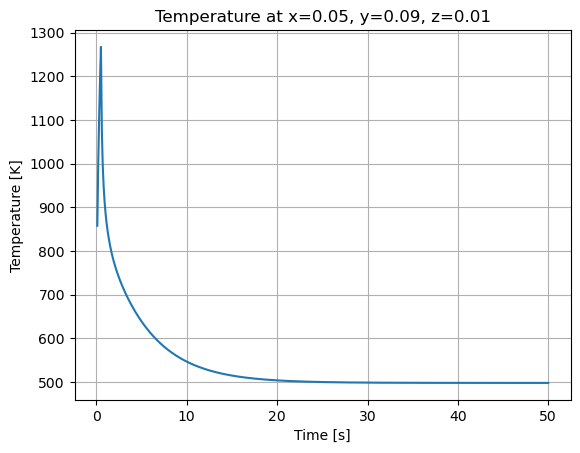

[output:0]

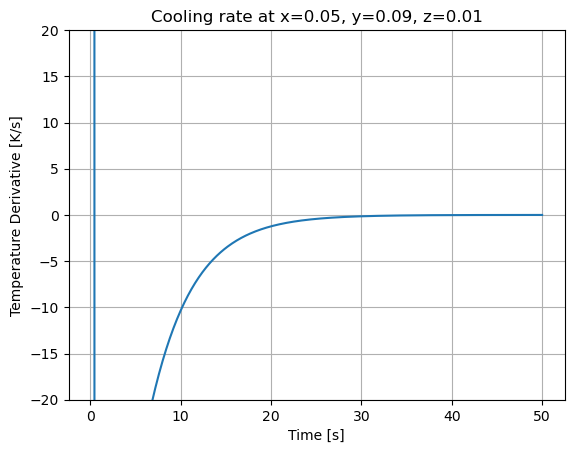

In [ ]:
%%px 

def create_figures(Tracker_time, Tracker_Temperature, Tracker_derivative, save_name = None):
    if MPI.COMM_WORLD.Get_rank() == 0: # only print on one rank
        if save_name is None:
            save_name = "saved_figures"

        plt.figure()
        plt.plot(Tracker_time, Tracker_Temperature)
        plt.xlabel("Time [s]")
        plt.ylabel("Temperature [K]")
        plt.title(f"Temperature at x={x_probe[0, 0]}, y={x_probe[0, 1]}, z={x_probe[0, 2]}")
        #plt.xlim(0, 20)
        plt.grid()
        plt.savefig(save_name + f"{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}.png")
        plt.show()

        plt.figure()
        plt.plot(Tracker_time, Tracker_derivative)
        plt.xlabel("Time [s]")
        plt.ylabel("Temperature Derivative [K/s]")
        plt.title(f"Cooling rate at x={x_probe[0, 0]}, y={x_probe[0, 1]}, z={x_probe[0, 2]}")
        plt.ylim(-20, 20)
        #plt.xlim(0, 20)
        plt.grid()
        plt.savefig(save_name + "_derivative_" + f"{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}.png")
        plt.show()


In [ ]:
%%px

Tracker_time, Tracker_Temperature, Tracker_derivative, list_T_n, list_mesh = run_simulation()


In [ ]:
%%px 

create_figures(Tracker_time, Tracker_Temperature, Tracker_derivative, "myfigures")


In [ ]:
%%px

create_gif(Tracker_time, list_T_n, list_mesh, frames = slice(0, 3), save_name = "myname")
